# Cell Cycle Analysis

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import seaborn as sns
import matplotlib.pyplot as plt
from openpyxl import load_workbook
import os

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier  # or any classifier of your choice
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.inspection import permutation_importance
import shap


/home2/poorvi.c/miniconda3/envs/research/lib/python3.12/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
/home2/poorvi.c/miniconda3/envs/research/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def read_file(file, index=False):
    file_ext = os.path.splitext(file)[1].lower()
    
    if file_ext == '.xlsx':
        if index:
            data = pd.read_excel(file, index_col=0)
        else:
            data = pd.read_excel(file)
    
    elif file_ext == '.csv':
        if index:
            data = pd.read_csv(file, index_col=0)
        else:
            data = pd.read_csv(file)
    
    elif file_ext == '.txt':
        data = pd.read_csv(file, header=None, names=['Gene'])
        data['Gene'] = data['Gene'].str.strip()
    
    else:
        raise ValueError(f"Unsupported file format: {file_ext}. Supported formats are: .xlsx, .csv, .txt")
    
    return data


In [3]:
# derive the combined_gene_list (combination of all the three way conserved gene lists)
file = "../../results/module_comparison/three_way_module_associations_significant.csv"
associations = read_file(file)
def parse_gene_list(list_string):
    cleaned = list_string.strip('[]').split(', ')
    return [gene.strip().strip("'\"") for gene in cleaned]

associations["genes"] = associations["genes"].apply(parse_gene_list)

combined_gene_list = [gene for gene_list in associations["genes"] for gene in gene_list]
len(combined_gene_list)

172

In [4]:
# process RATs list of genes
rats = pd.read_excel('../../data/rats.xlsx', header=None)
rats.columns = ['gene']
rats = rats['gene'].tolist()
print(len(rats))

def process_rats(rats):
    processed_rats = []
    for gene in rats:
        if gene != '':
            if "///" in str(gene):
                genes = gene.split("///")
                for i in genes:
                    processed_rats.append(i.replace('/', '').replace(' ', ''))
            else:
                processed_rats.append(str(gene).replace('/', '').replace(' ', ''))
    return processed_rats

processed_rats = process_rats(rats)
rats = list(np.unique(processed_rats))
print(len(rats))

454
350


In [11]:
data_liver = read_file('../../data/GSE145780_liver.csv', index=True)
meta_liver = read_file('../../data/liver_meta.xlsx', index=True)
data_kidney = read_file("../../data/GSE192444_kidney.csv", index=True)
meta_kidney = read_file('../../data/kidney_meta.xlsx', index=True)
data_heart = read_file("../../data/GSE272655_heart.csv", index=True)
meta_heart = read_file('../../data/heart_meta.xlsx', index=True)

### ML Utilities

In [5]:
# function to produce a subset of the expression matrix given a list of genes
def filter_genes(data, genes):
    genes = [gene for gene in genes if gene in data.columns]
    data = data[genes]
    return data

In [6]:
num_folds = 10
skf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

In [7]:
def mean_ci(values, confidence=0.95):
    values = np.array(values)
    mean = np.mean(values)
    se = np.std(values, ddof=1) / np.sqrt(len(values))
    z = 1.96  # 95% CI
    lower = mean - z * se
    upper = mean + z * se
    return mean, lower, upper

In [8]:
def avg_acc_auc(X, y, model_type="rndm"):
    accuracies = []
    aucs = []
    best_auc = 0
    best_model = None

    for train_index, test_index in skf.split(X, y):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        if model_type == "rndm":
            clf = RandomForestClassifier(n_estimators=100, random_state=42)
            clf.fit(X_train, y_train)
            
        elif model_type == "svm":
            clf = Pipeline([
                ('scaler', StandardScaler()),
                ('svm', SVC(kernel='linear', C=1.0, probability=True, random_state=42))
            ])
            clf.fit(X_train, y_train)
            
        elif model_type == "lasso":
            clf = Pipeline([
                ('scaler', StandardScaler()),
                ('lasso', LogisticRegression(penalty='l1', C=0.1, solver='liblinear', random_state=42))
            ])
            clf.fit(X_train, y_train)

        if model_type == "rndm":
            y_pred = clf.predict(X_test)
            y_pred_proba = clf.predict_proba(X_test)[:, 1]
        else:
            y_pred = clf.predict(X_test)
            y_pred_proba = clf.predict_proba(X_test)[:, 1]
            
        accuracy = accuracy_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_pred_proba)
        
        accuracies.append(accuracy)
        aucs.append(auc)

        if auc > best_auc:
            best_auc = auc
            best_model = clf
    
    if model_type == "rndm":
        feature_importance = best_model.feature_importances_
    elif model_type == "svm":
        feature_importance = np.abs(best_model.named_steps['svm'].coef_[0])
    elif model_type == "lasso":
        feature_importance = np.abs(best_model.named_steps['lasso'].coef_[0])

            
    return accuracies, aucs, best_model, feature_importance if best_model is not None else None

def get_train_test_gap(model, X, y):
    train_scores = []
    test_scores = []
    
    for train_idx, test_idx in skf.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        if hasattr(model, 'fit'):
            model.fit(X_train, y_train)
            train_score = model.score(X_train, y_train)
            test_score = model.score(X_test, y_test)
        else:  
            model.fit(X_train, y_train)
            train_score = model.score(X_train, y_train)
            test_score = model.score(X_test, y_test)
            
        train_scores.append(train_score)
        test_scores.append(test_score)
    
    return np.mean(train_scores) - np.mean(test_scores)


def compare_models(data, meta, category, genes_list, models=["rndm", "svm", "lasso"]):
    results = []
    
    for model_type in models:
        X = filter_genes(data, genes_list)
        y = meta[category]
        
        accuracies, aucs, best_model, _ = avg_acc_auc(X, y, model_type)
        
        mean_auc, lower_auc, upper_auc = mean_ci(aucs)
        mean_acc, lower_acc, upper_acc = mean_ci(accuracies)

        results.append({
            'model': model_type,
            'accuracy_mean': mean_acc,
            'accuracy_ci_lower': lower_acc,
            'accuracy_ci_upper': upper_acc,
            'std_acc': np.std(accuracies),
            'std_auc': np.std(aucs),
            'auc_mean': mean_auc,
            'auc_ci_lower': lower_auc,
            'auc_ci_upper': upper_auc,
            'train_test_gap': get_train_test_gap(best_model, X, y) if best_model is not None else None
        })

    return pd.DataFrame(results)

In [9]:
def get_feature_importances(data, meta, category, genes, model_type="lasso"):
    overlap = [gene for gene in genes if gene in data.columns]
    X = filter_genes(data, overlap)
    y = meta[category]
    accuracies, aucs, best_model, feature_importance = avg_acc_auc(X, y, model_type)
    print(np.mean(accuracies), np.mean(aucs))

    builtin_importance = pd.Series(feature_importance, index=X.columns).sort_values(ascending=False)

    perm_imp = permutation_importance(best_model, X, y, n_repeats=10, random_state=42, scoring='roc_auc')
    permutation_importance_scores = pd.Series(perm_imp.importances_mean, index=X.columns).sort_values(ascending=False)

    try:
        if hasattr(best_model, 'named_steps'):
            if 'lasso' in best_model.named_steps:
                model_for_shap = best_model.named_steps['lasso']
                X_scaled = best_model.named_steps['scaler'].transform(X)
                explainer = shap.LinearExplainer(model_for_shap, X_scaled)
                shap_values = explainer.shap_values(X_scaled)
            elif 'svm' in best_model.named_steps:
                model_for_shap = best_model.named_steps['svm']
                X_scaled = best_model.named_steps['scaler'].transform(X)
                explainer = shap.LinearExplainer(model_for_shap, X_scaled)
                shap_values = explainer.shap_values(X_scaled)
        else:
            explainer = shap.TreeExplainer(best_model)
            shap_values = explainer.shap_values(X)
            
            if isinstance(shap_values, list):
                shap_values = shap_values[1]
            elif len(shap_values.shape) == 3:
                shap_values = shap_values[:, :, 1]
                
    except Exception as e:
        print(f"TreeExplainer failed with error: {e}")
        print("Falling back to general Explainer...")
        
        explainer = shap.Explainer(best_model, X)
        shap_values = explainer(X).values
        
        if len(shap_values.shape) == 3:
            shap_values = shap_values[:, :, 1]
        elif len(shap_values.shape) == 2 and shap_values.shape[1] != X.shape[1]:
            if shap_values.shape[1] == 2:
                print(f"Warning: Unexpected SHAP output shape {shap_values.shape}")
                print("SHAP values should have shape (n_samples, n_features)")
                print("Check your model and data setup")
                return None

    if len(shap_values.shape) != 2 or shap_values.shape[1] != X.shape[1]:
        print(f"Error: SHAP values have shape {shap_values.shape}, expected ({X.shape[0]}, {X.shape[1]})")
        return None

    shap_importance_scores = pd.Series(
        np.abs(shap_values).mean(axis=0), 
        index=X.columns
    ).sort_values(ascending=False)
    
    importance_df = pd.DataFrame({
        'builtin': builtin_importance,
        'permutation': permutation_importance_scores,
        'shap': shap_importance_scores
    })

    for col in importance_df.columns:
        importance_df[col] = (importance_df[col] - importance_df[col].min()) / (importance_df[col].max() - importance_df[col].min())

    importance_df['consensus'] = importance_df.mean(axis=1)
    consensus_ranking = importance_df.sort_values('consensus', ascending=False)
    print("Top 10 features by consensus:")
    print(consensus_ranking.head(10))

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    builtin_importance.head(10).plot(kind='barh', ax=axes[0,0], title='Built-in Importance')
    permutation_importance_scores.head(10).plot(kind='barh', ax=axes[0,1], title='Permutation Importance')
    shap_importance_scores.head(10).plot(kind='barh', ax=axes[1,0], title='SHAP Importance')
    consensus_ranking['consensus'].head(10).plot(kind='barh', ax=axes[1,1], title='Consensus Ranking')
    plt.tight_layout()
    plt.show()

    shap.summary_plot(shap_values, X, plot_type="bar", max_display=15)
    shap.summary_plot(shap_values, X, max_display=15)
    return consensus_ranking['consensus']

In [10]:
cell_cycle_genes = read_file("../../results/module_comparison/conserved_group_2_genes.txt")['Gene'].tolist()

# overlap cell_cycle_genes with rats
df = {"genes": [], "in_rats":[]}
for i in cell_cycle_genes:
    df["genes"].append(i)
    df["in_rats"].append(i in rats)
    
df = pd.DataFrame(df)
df

,genes,in_rats
0,ANLN,False
1,ASPM,False
2,BUB1,False
3,BUB1B,False
4,CCNA2,False
5,CCNB1,False
6,CDKN3,False
7,CENPA,False
8,CENPF,False
9,CEP55,False


0.7999999999999999 0.8375990675990674
Top 10 features by consensus:
         builtin  permutation      shap  consensus
CCNB1   1.000000     1.000000  1.000000   1.000000
BUB1    0.575326     0.349992  0.551854   0.492391
CEP55   0.444185     0.210704  0.398101   0.350997
EZH2    0.251131     0.090302  0.248747   0.196727
RRM2    0.130079     0.019957  0.136279   0.095439
NUSAP1  0.033277     0.000495  0.034671   0.022814
ASPM    0.000000     0.000000  0.000000   0.000000
ANLN    0.000000     0.000000  0.000000   0.000000
CENPA   0.000000     0.000000  0.000000   0.000000
CDKN3   0.000000     0.000000  0.000000   0.000000


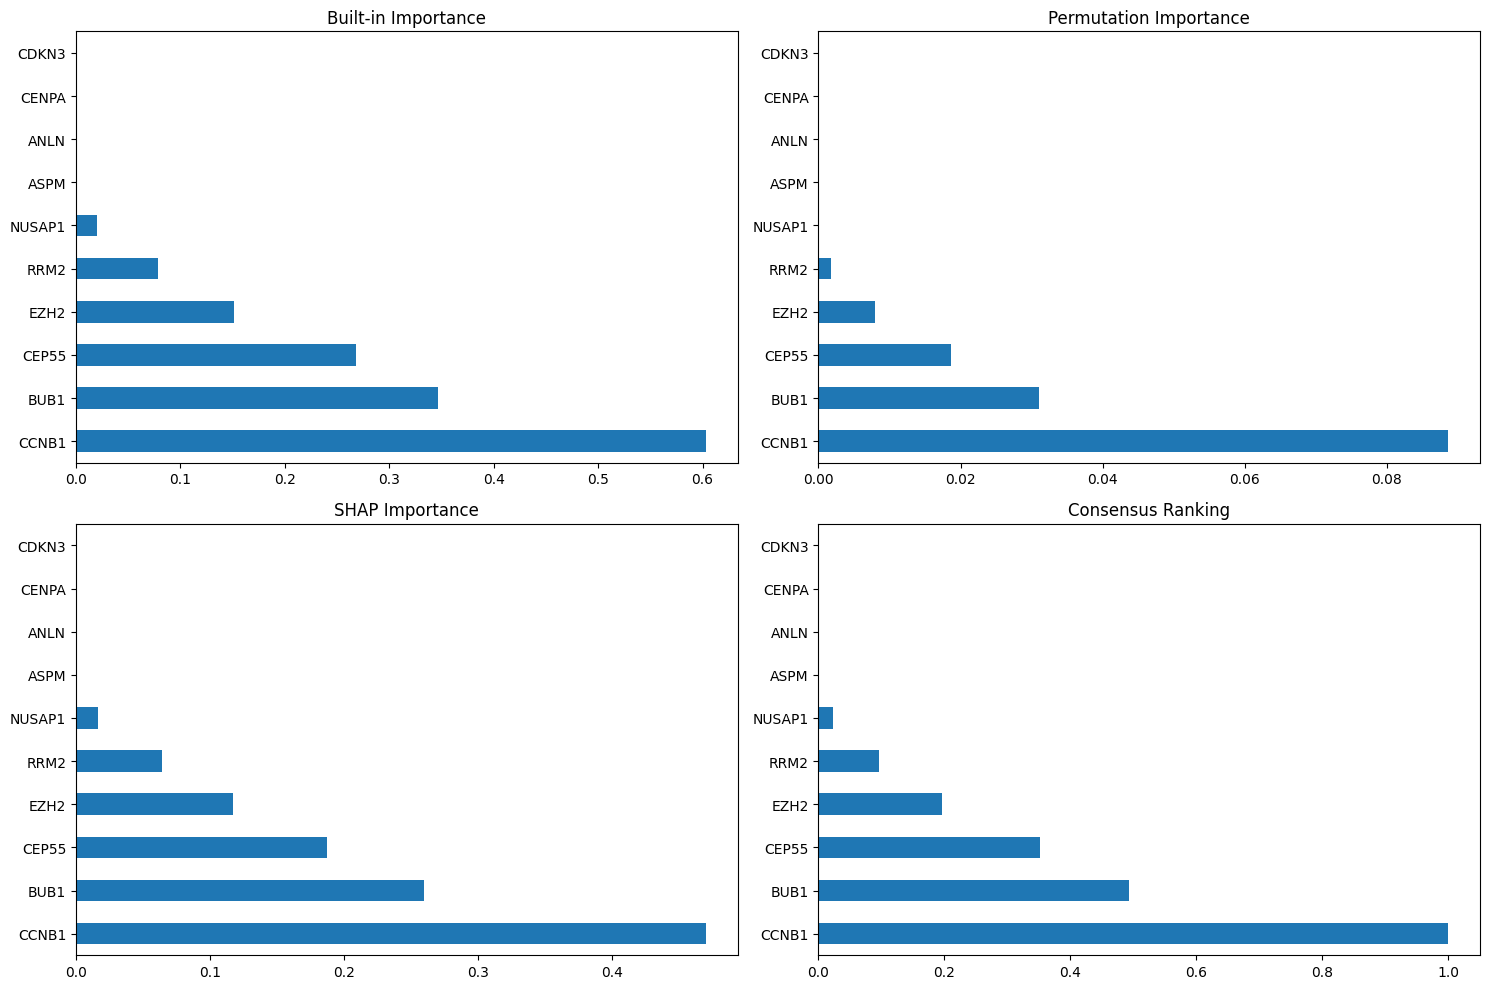

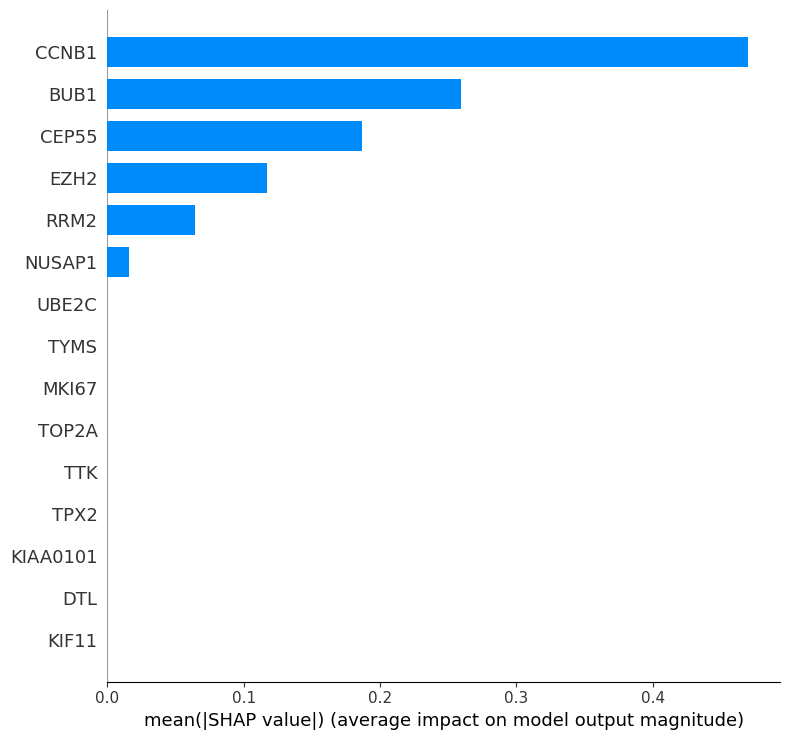

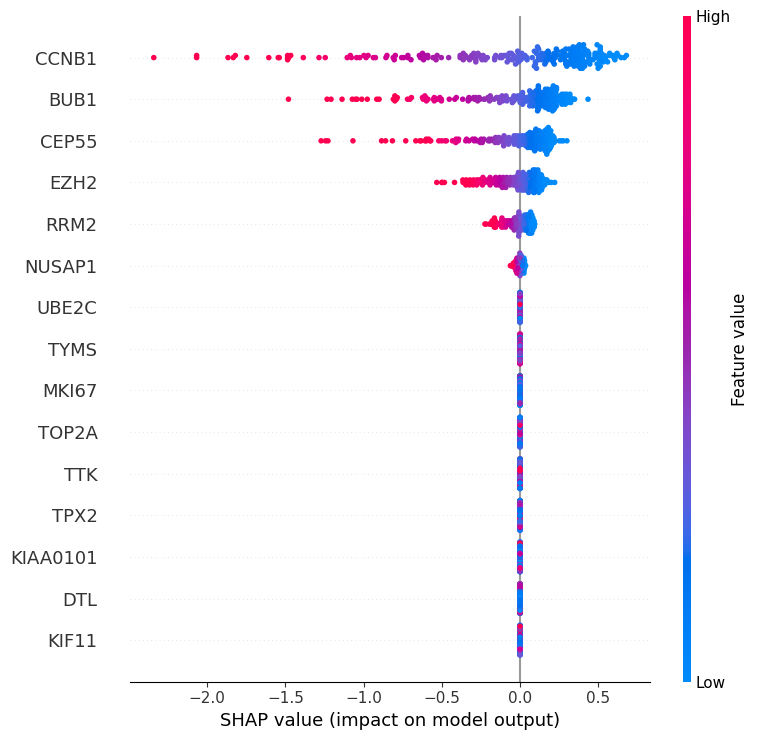

In [12]:
liver_cell_features = get_feature_importances(data_liver, meta_liver, "classes", cell_cycle_genes, model_type="lasso")

0.71 0.7754975280710574
Top 10 features by consensus:
       builtin  permutation  shap  consensus
EZH2       1.0          1.0   1.0        1.0
ANLN       0.0          0.0   0.0        0.0
BUB1       0.0          0.0   0.0        0.0
ASPM       0.0          0.0   0.0        0.0
CCNA2      0.0          0.0   0.0        0.0
CCNB1      0.0          0.0   0.0        0.0
CDKN3      0.0          0.0   0.0        0.0
BUB1B      0.0          0.0   0.0        0.0
CENPA      0.0          0.0   0.0        0.0
CENPF      0.0          0.0   0.0        0.0


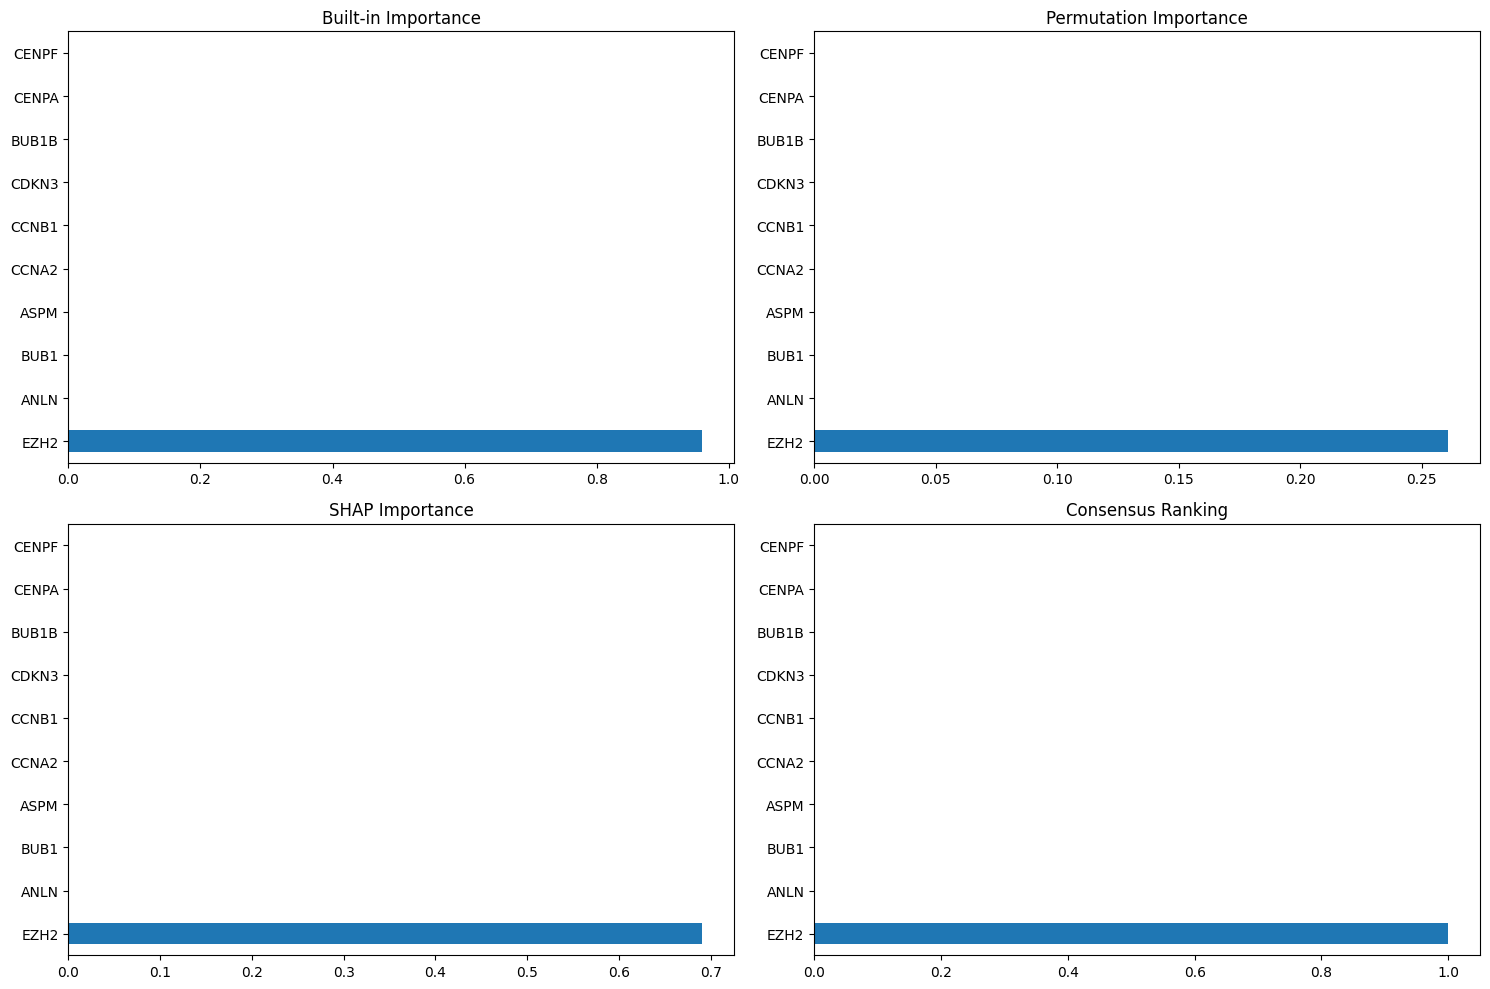

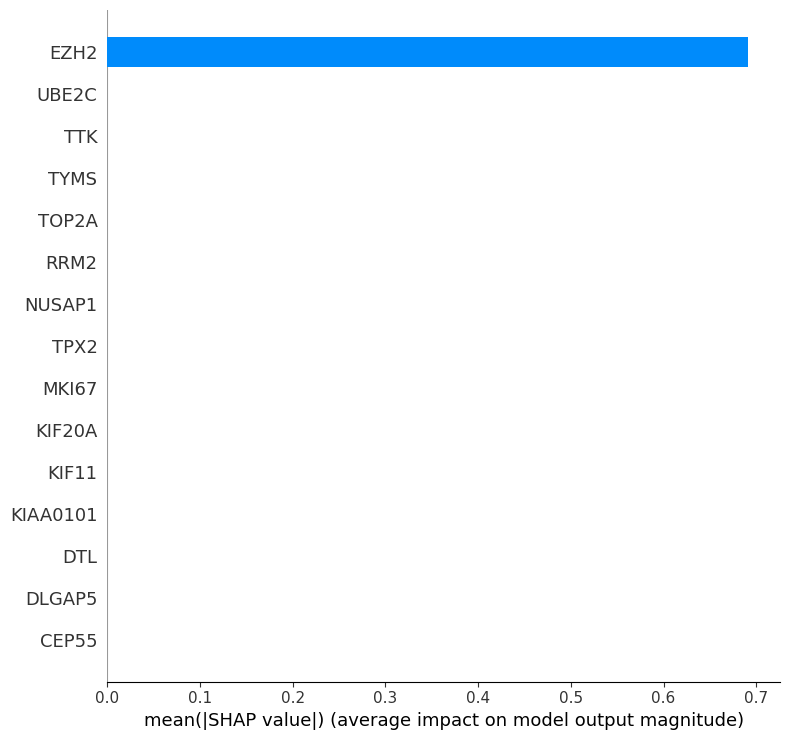

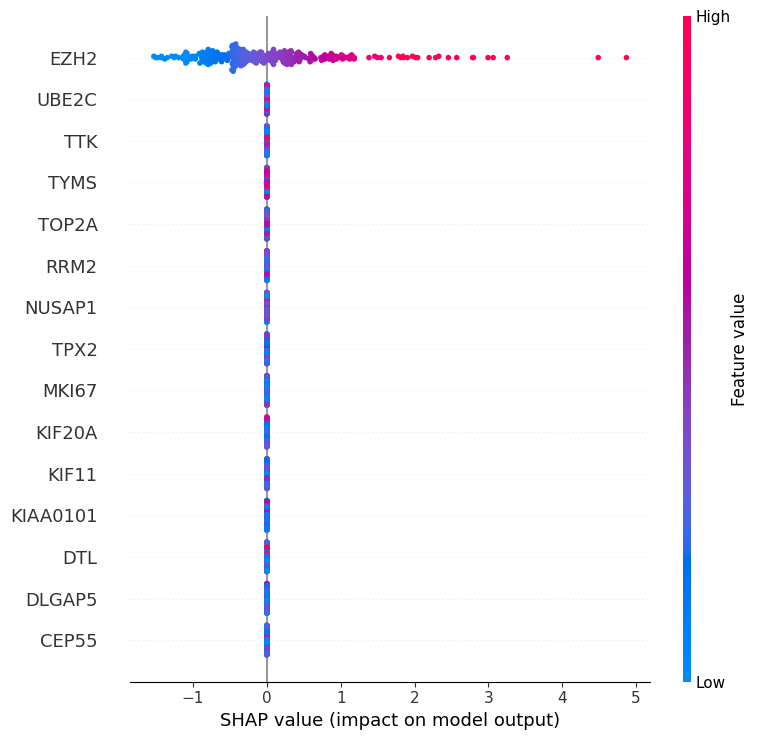

In [13]:
kidney_cell_features = get_feature_importances(data_kidney, meta_kidney, "group", cell_cycle_genes, model_type="lasso")

0.8032967032967033 0.8961111111111111
Top 10 features by consensus:
           builtin  permutation      shap  consensus
EZH2      1.000000     1.000000  1.000000   1.000000
UBE2C     0.294471     0.131884  0.321039   0.249131
KIAA0101  0.023864     0.001104  0.026884   0.017284
ANLN      0.000000     0.000000  0.000000   0.000000
CCNA2     0.000000     0.000000  0.000000   0.000000
ASPM      0.000000     0.000000  0.000000   0.000000
BUB1      0.000000     0.000000  0.000000   0.000000
BUB1B     0.000000     0.000000  0.000000   0.000000
CENPA     0.000000     0.000000  0.000000   0.000000
CDKN3     0.000000     0.000000  0.000000   0.000000


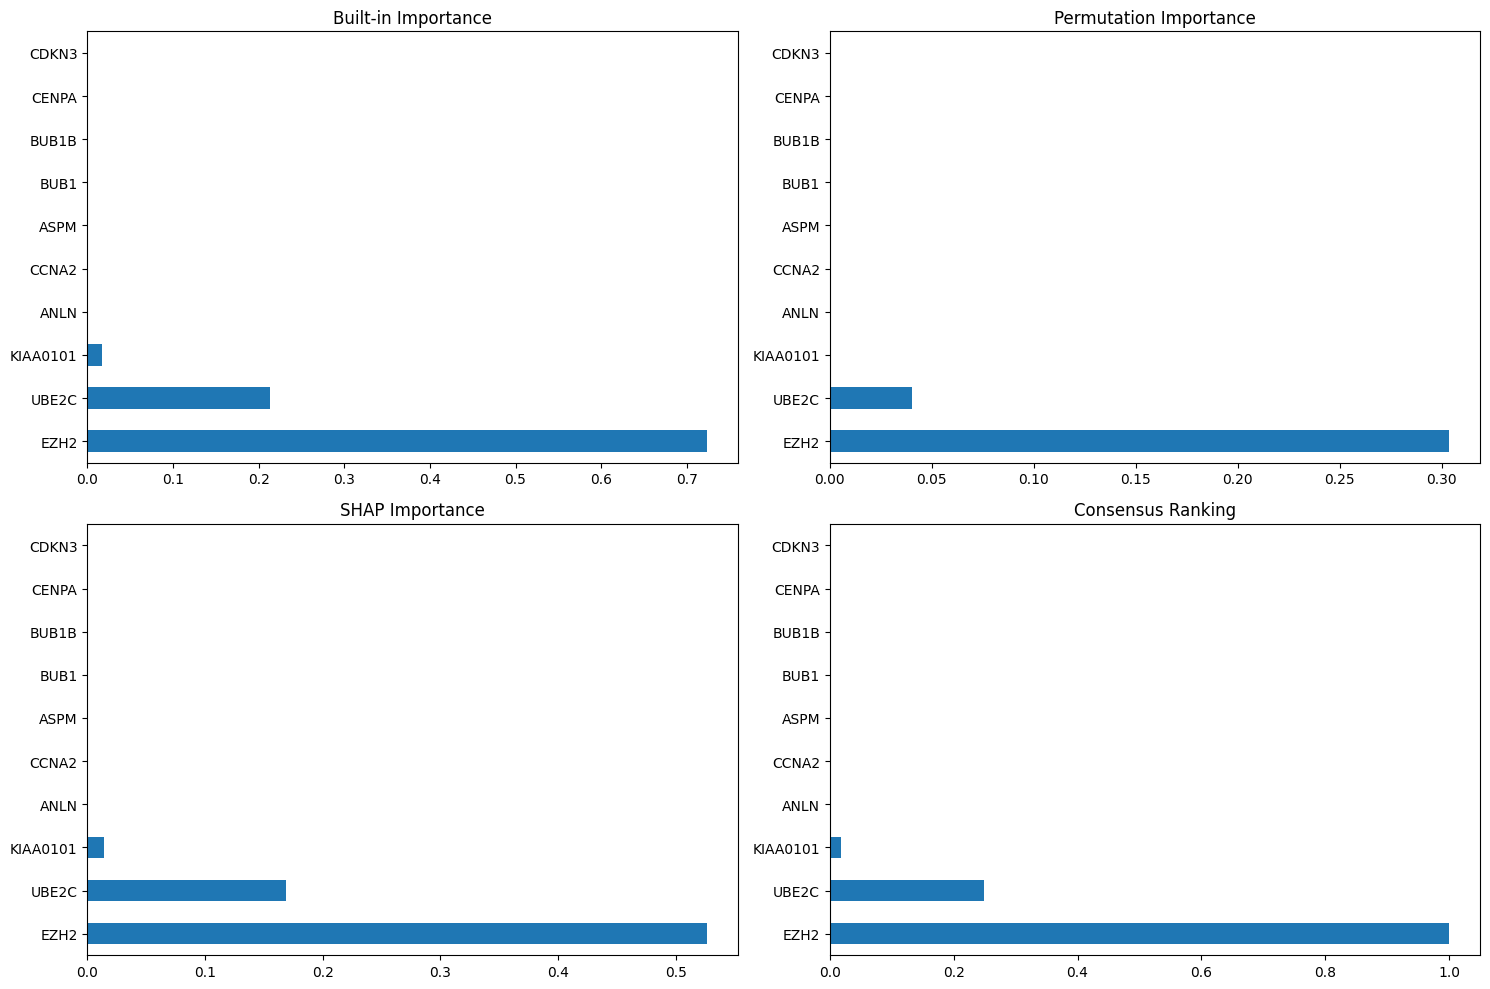

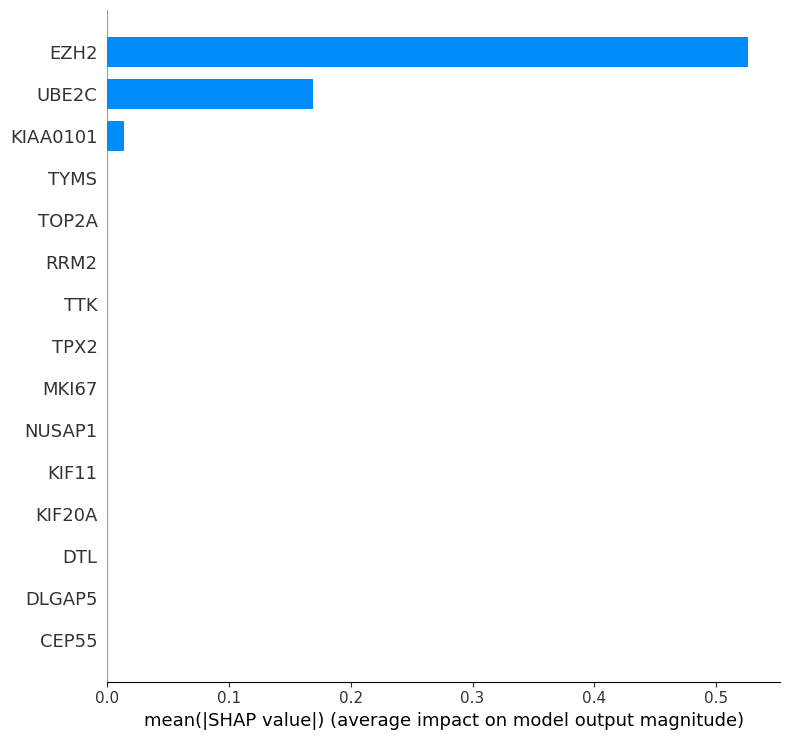

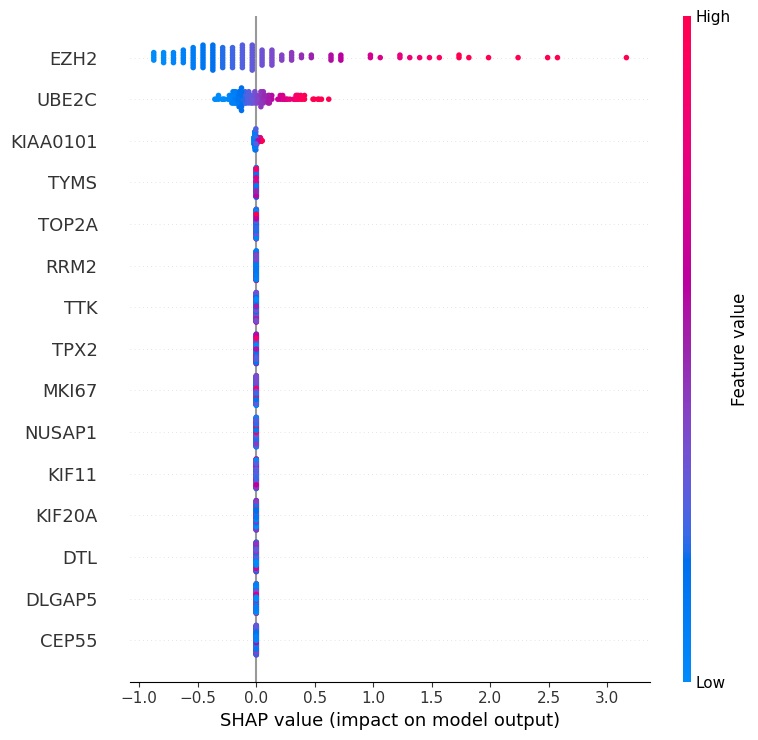

In [14]:
heart_cell_features = get_feature_importances(data_heart, meta_heart, "group", cell_cycle_genes, model_type="lasso")

### Cell Cycle heatmaps